In [1]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
print("bw2data version", bd.__version__)
print("bw2io version", bi.__version__)
print("bw2calc version", bi.__version__)

bw2data version (4, 5, 1)
bw2io version 0.9.14
bw2calc version 0.9.14


In [3]:
bd.projects

Brightway2 projects manager with 3 objects:
	bw25-tuto
	bw25-tutorial
	default
Use `projects.report()` to get a report on all projects.

In [4]:
bd.projects.dir

PosixPath('/Users/cooperzvegintzov/Library/Application Support/Brightway3/default.c21f969b')

In [5]:
bd.projects.set_current("bw25-tuto")

15:08:56-0800 [info     ] Applying automatic update: 4.0 database search directories FTS5


In [6]:
bd.projects

Brightway2 projects manager with 3 objects:
	bw25-tuto
	bw25-tutorial
	default
Use `projects.report()` to get a report on all projects.

In [7]:
bd.databases

Databases dictionary with 0 objects

In [8]:
bi.remote.install_project('forwast', 'bw25-tutorial')

Restoring project backup archive - this could take a few minutes...


ValueError: Project bw25-tutorial already exists, set `overwrite_existing=True` to overwrite

In [9]:
bd.projects

Brightway2 projects manager with 3 objects:
	bw25-tuto
	bw25-tutorial
	default
Use `projects.report()` to get a report on all projects.

In [10]:
bd.projects.set_current("bw25-tutorial")

15:09:49-0800 [info     ] Applying automatic update: 4.0 database search directories FTS5
15:09:49-0800 [info     ] Reindexing database ecoinvent-3.9.1-biosphere
15:09:50-0800 [info     ] Reindexing database forwast   


In [11]:
bd.databases

Databases dictionary with 3 object(s):
	Water bottle LCA
	ecoinvent-3.9.1-biosphere
	forwast

In [12]:
fw = bd.Database("forwast")
fw

Brightway2 SQLiteBackend: forwast

In [13]:
print(
    "The imported ecoinvent database is of type {} and has a length of {}.".format(
        type(fw), len(fw)
    )
)

The imported ecoinvent database is of type <class 'bw2data.backends.base.SQLiteBackend'> and has a length of 277.


/Users/cooperzvegintzov/miniconda3/envs/env_bw25/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 9.77e+12)
  warnings.warn(msg, UmfpackWarning)


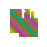

In [14]:
fw.graph_technosphere()

In [15]:
random_act = fw.random()
random_act.as_dict()

{'products': [{'location': 'GLO',
   'unit': 'kilogram',
   'output': ['forwast', 'd1e4827a07e4fc9fc6eebf9933defa1b'],
   'amount': 1.0,
   'input': ['forwast', 'd1e4827a07e4fc9fc6eebf9933defa1b'],
   'categories': [],
   'loc': 1.0,
   'type': 'production',
   'name': '_29 Textiles, DK',
   'uncertainty type': 0}],
 'categories': ['Input Output', 'Denmark 2003'],
 'filename': '/Users/marie/Downloads/FORWAST-ecospold1/FORWAST-ecospold100057.XML',
 'type': 'process',
 'comment': 'Location:  Unspecified\nTechnology:  Unspecified\nTime period:  Unspecified',
 'location': 'GLO',
 'unit': 'kilogram',
 'code': 'd1e4827a07e4fc9fc6eebf9933defa1b',
 'production amount': 1.0,
 'name': '_29 Textiles, DK',
 'database': 'forwast',
 'id': 4736,
 'reference product': '_29 Textiles, DK'}

In [16]:
for exc in random_act.exchanges():
    print(exc)

Exchange: 1.0 kilogram '_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003']) to '_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])>
Exchange: 2.09323373221795e-06 kilogram '__1 Bovine meat and milk, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003']) to '_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])>
Exchange: 4.04439193577473e-07 kilogram '__2 Pigs, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003']) to '_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])>
Exchange: 1.9142016339391e-05 kilogram '__3 Poultry and animals n.e.c., DK' (kilogram, GLO, ['Input Output', 'Denmark 2003']) to '_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])>
Exchange: 0.00268766872346043 kilogram '__4 Grain crops, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003']) to '_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])>
Exchange: 0.133111025767244 kilogram '__5 Sugar beets, DK' (kilogram, GLO, ['Inp

In [17]:
random_act["code"]

'd1e4827a07e4fc9fc6eebf9933defa1b'

In [18]:
fw.get(random_act["code"])

'_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])

In [19]:
# Getting an activity's key
random_act.key

('forwast', 'd1e4827a07e4fc9fc6eebf9933defa1b')

In [20]:
# Getting an activity's name using its key
bd.get_activity(random_act.key)

'_29 Textiles, DK' (kilogram, GLO, ['Input Output', 'Denmark 2003'])

In [21]:
fg_db = bi.ExcelImporter("excel_importer_example.xlsx")

Extracted 2 worksheets in 5.50 seconds


In [22]:
fg_db.apply_strategies()
fg_db.match_database(fields=["name", "unit", "reference product", "location"])

Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 14 strategies in 0.11 seconds
Applying strategy: link_iterable_by_fields


In [23]:
# Need to match fg_db to ecoinvent
fg_db.match_database(
    "forwast", fields=["name", "unit", "location", "reference product"]
)

Applying strategy: link_iterable_by_fields


In [24]:
fg_db.match_database("forwast", fields=["name", "categories", "location"])

Applying strategy: link_iterable_by_fields


In [25]:
fg_db.statistics()

Graph statistics for `Water bottle LCA` importer:
2 graph nodes:
	process: 2
5 graph edges:
	technosphere: 4
	biosphere: 1
1 edges to the following databases:
	Water bottle LCA: 1
4 unique unlinked edges (4 total):
	technosphere: 3
	biosphere: 1




(2, 5, 4, 0)

In [26]:
fg_db.write_database()

15:10:16-0800 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


  0%|                                                     | 0/2 [00:00<?, ?it/s]


InvalidExchange: 

In [27]:
bd.databases

Databases dictionary with 3 object(s):
	Water bottle LCA
	ecoinvent-3.9.1-biosphere
	forwast

In [28]:
fg_db_u = bi.ExcelImporter("excel_importer_example_w_unlinked.xlsx")

Extracted 2 worksheets in 0.02 seconds


In [29]:
fg_db_u.apply_strategies()
fg_db_u.match_database(fields=["name", "unit", "reference product", "location"])

Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 14 strategies in 0.17 seconds
Applying strategy: link_iterable_by_fields


In [30]:
fg_db_u.match_database(
    "forwast", fields=["name", "unit", "location", "reference product"]
)

Applying strategy: link_iterable_by_fields


In [31]:
fg_db_u.match_database("forwast", fields=["name", "categories", "location"])

Applying strategy: link_iterable_by_fields


In [32]:
fg_db_u.statistics()

Graph statistics for `Water bottle LCA` importer:
2 graph nodes:
	process: 2
5 graph edges:
	technosphere: 4
	biosphere: 1
1 edges to the following databases:
	Water bottle LCA: 1
4 unique unlinked edges (4 total):
	technosphere: 3
	biosphere: 1




(2, 5, 4, 0)

In [33]:
list(fg_db_u.unlinked)

[{'name': 'treatment of aluminium scrap, post-consumer, prepared for recycling, at remelter',
  'amount': 0.33,
  'unit': 'kilogram',
  'database': 'ecoinvent-391-cutoff',
  'categories': ('None',),
  'location': 'RER',
  'type': 'technosphere',
  'reference product': 'aluminium, wrought alloy',
  'uncertainty type': 0,
  'loc': 0.33},
 {'name': 'impact extrusion of aluminium, deformation stroke',
  'amount': 0.33,
  'unit': 'kilogram',
  'database': 'ecoinvent-391-cutoff',
  'categories': ('None',),
  'location': 'RER',
  'type': 'technosphere',
  'reference product': 'impact extrusion of aluminium, deformation stroke',
  'uncertainty type': 0,
  'loc': 0.33},
 {'name': 'Carbon dioxide, fossil',
  'amount': 0.1,
  'unit': 'kilogram',
  'database': 'biosphere3',
  'categories': ('air',),
  'type': 'biosphere',
  'reference product': 'none',
  'uncertainty type': 0},
 {'name': 'market group for tap water',
  'amount': 1,
  'unit': 'kilogram',
  'database': 'ecoinvent-391-cutoff',
  'cat

In [34]:
fg_db_u.write_excel()

Wrote matching file to:
/Users/cooperzvegintzov/Library/Application Support/Brightway3/bw25-tutorial.f2bdefac/output/db-matching-Water-bottle-LCA.xlsx


PosixPath('/Users/cooperzvegintzov/Library/Application Support/Brightway3/bw25-tutorial.f2bdefac/output/db-matching-Water-bottle-LCA.xlsx')

In [36]:
results = fw.search("water")
for item in results:
    print(item['name'], "|", item['location'], "|", item['unit'])

_77 Water, fresh, EU27 | GLO | EUR2003
_68 Water, fresh, DK | GLO | EUR2003
_66 Electricity, steam and hot water, DK | GLO | kilowatt hour
_75 Electricity, steam and hot water, EU27 | GLO | kilowatt hour
115 Waste treatment, Waste water treatment, other, EU27 | GLO | kilogram
105 Waste treatment, Waste water treatment, food, DK | GLO | kilogram
114 Waste treatment, Waste water treatment, food, EU27 | GLO | kilogram
106 Waste treatment, Waste water treatment, other, DK | GLO | kilogram


In [37]:
bd.databases

Databases dictionary with 3 object(s):
	Water bottle LCA
	ecoinvent-3.9.1-biosphere
	forwast

In [39]:
wb = bd.Database("Water bottle LCA")

# Print all activities that are in our water bottle database.
for act in wb:
    print(act)